In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

Data Collection & Pre-Processing

In [2]:
df = pd.read_csv("C:/Users/USER/Downloads/Data analysis/datasets/mail_data.csv")
display(df.head())

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
#Check for missing values in the dataframe
display(df.isnull().sum())

Category    0
Message     0
dtype: int64

In [4]:
print(df)

     Category                                            Message
0         ham  Go until jurong point, crazy.. Available only ...
1         ham                      Ok lar... Joking wif u oni...
2        spam  Free entry in 2 a wkly comp to win FA Cup fina...
3         ham  U dun say so early hor... U c already then say...
4         ham  Nah I don't think he goes to usf, he lives aro...
...       ...                                                ...
5567     spam  This is the 2nd time we have tried 2 contact u...
5568      ham               Will ü b going to esplanade fr home?
5569      ham  Pity, * was in mood for that. So...any other s...
5570      ham  The guy did some bitching but I acted like i'd...
5571      ham                         Rofl. Its true to its name

[5572 rows x 2 columns]


In [5]:
#Show summary statistics for the dataframe
display(df.describe(include='all'))

,Category,Message
count,5572,5572
unique,2,5157
top,ham,"Sorry, I'll call later"
freq,4825,30



Visualize the distribution of 'Category' using a countplot

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\USER\AppData\Local\Temp\ipykernel_29804\2520227018.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Category', data=df, palette='viridis')


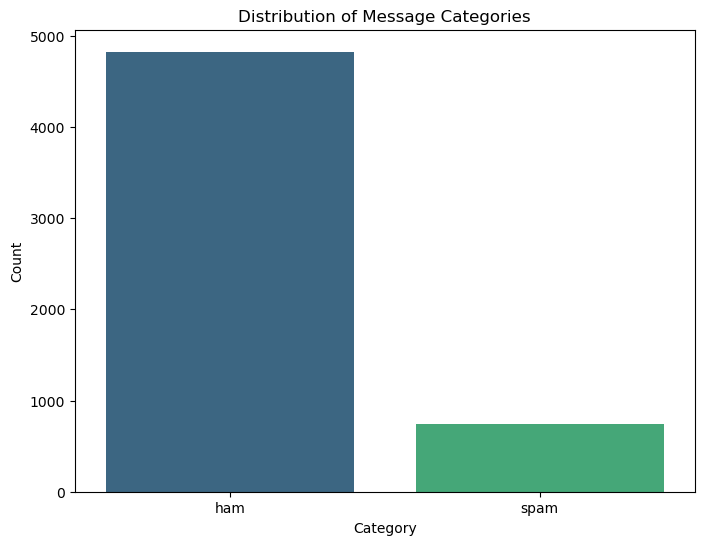

In [7]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Category', data=df, palette='viridis')
plt.title('Distribution of Message Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

I will perform text preprocessing on the 'Message' column. This will involve converting text to lowercase, removing punctuation, and removing stopwords. I'll add the processed text to a new column called 'cleaned_message'.


In [8]:
import nltk
from nltk.corpus import stopwords
import string

# Download stopwords if not already downloaded
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')
    nltk.download('punkt') # often useful for tokenization

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


In [9]:
# Function to remove punctuation
def remove_punctuation(text):
    return ''.join([char for char in text if char not in string.punctuation])

# Function to remove stopwords
def remove_stopwords(text):
    words = [word for word in text.split() if word.lower() not in stopwords.words('english')]
    return ' '.join(words)

In [10]:
# Apply preprocessing steps to the 'Message' column
df['cleaned_message'] = df['Message'].apply(lambda x: x.lower())
df['cleaned_message'] = df['cleaned_message'].apply(remove_punctuation)
df['cleaned_message'] = df['cleaned_message'].apply(remove_stopwords)

display(df[['Message', 'cleaned_message']].head())

,Message,cleaned_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


## Feature Engineering

I will convert the text messages into numerical feature vectors using TF-IDF. I will also convert the 'Category' column into numerical labels (0 for 'ham' and 1 for 'spam').

In [11]:
# Convert 'Category' to numerical labels
df['Category'] = df['Category'].map({'ham': 0, 'spam': 1})

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting to 5000 features for practical reasons

# Fit and transform the 'cleaned_message' column
X = tfidf_vectorizer.fit_transform(df['cleaned_message'])
y = df['Category']

print("Shape of X (features):", X.shape)
print("Shape of y (labels):", y.shape)
print("First 5 feature vectors:\n", X[:5])
print("First 5 labels:\n", y[:5])

Shape of X (features): (5572, 5000)
Shape of y (labels): (5572,)
First 5 feature vectors:
 <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 50 stored elements and shape (5, 5000)>
  Coords	Values
  (0, 1703)	0.17967692943770738
  (0, 3037)	0.3096893361549061
  (0, 1103)	0.30663115902064647
  (0, 593)	0.3010831791557063
  (0, 810)	0.3344948583740888
  (0, 1741)	0.22037677077866427
  (0, 4782)	0.27304599235128935
  (0, 2148)	0.3344948583740888
  (0, 809)	0.37797108322930023
  (0, 967)	0.3344948583740888
  (0, 1727)	0.18581306575819237
  (0, 4552)	0.22575621056549497
  (1, 2684)	0.27394819096941153
  (1, 2163)	0.4080786340459629
  (1, 2066)	0.5233633708961773
  (1, 4684)	0.43136824573695387
  (1, 2697)	0.5462933604518558
  (2, 1600)	0.11511600975482722
  (2, 1397)	0.357394758009415
  (2, 4741)	0.18917074024829453
  (2, 1027)	0.19527285591335983
  (2, 4698)	0.14743898497020344
  (2, 1467)	0.46636532200644404
  (2, 1123)	0.20025864744190322
  (2, 1532)	0.18270641870650717
  (2,

## Data Splitting

I will split the data into training and testing sets to evaluate the model's performance. Typically, an 80/20 split is used, where 80% of the data is for training and 20% for testing. `stratify=y` is used to maintain the proportion of 'ham' and 'spam' messages in both the training and testing sets.

In [12]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (4457, 5000)
Shape of X_test: (1115, 5000)
Shape of y_train: (4457,)
Shape of y_test: (1115,)


## Model Training

I will now train a Logistic Regression model on the training data (`X_train`, `y_train`). Logistic Regression is a simple yet effective algorithm for binary classification tasks like spam detection.

In [13]:
# Initialize the Logistic Regression model
model = LogisticRegression(solver='liblinear') # 'liblinear' is a good choice for relatively small datasets

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


## Model Evaluation

I will now evaluate the trained Logistic Regression model on the test data (`X_test`, `y_test`) to assess its performance. We will calculate the accuracy score to understand how well the model predicts spam or ham messages.

In [14]:
# Make predictions on the test data
X_test_prediction = model.predict(X_test)

# Evaluate the model accuracy on the test data
test_data_accuracy = accuracy_score(y_test, X_test_prediction)

print(f"Accuracy on Test data: {test_data_accuracy:.4f}")

Accuracy on Test data: 0.9587


Generate a confusion matrix to visualize the prediction performance. This will show how many 'ham' messages were correctly classified, how many 'spam' messages were correctly classified, and how many of each were misclassified.

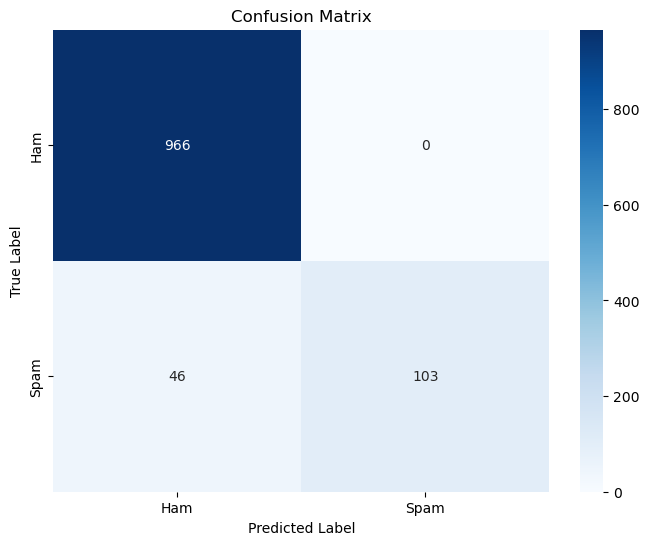

In [15]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generate the confusion matrix
cm = confusion_matrix(y_test, X_test_prediction)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## Predictive System

Now, let's create a function that can take a new message as input and predict whether it's 'ham' or 'spam' using our trained model.

In [16]:
def predict_spam(message):
    # Preprocess the message
    cleaned_message = message.lower()
    cleaned_message = remove_punctuation(cleaned_message)
    cleaned_message = remove_stopwords(cleaned_message)

    # Vectorize the cleaned message
    message_vector = tfidf_vectorizer.transform([cleaned_message])

    # Make prediction
    prediction = model.predict(message_vector)

    # Return 'spam' or 'ham'
    if prediction[0] == 1:
        return 'spam'
    else:
        return 'ham'

print("Predictive function `predict_spam` created.")

Predictive function `predict_spam` created.


### Demonstration

In [17]:
# Test with a 'spam' message example
spam_message = "Congratulations! You've won a free iPhone. Click here to claim your prize: http://example.com/prize"
print(f"Message: '{spam_message}'\nPrediction: {predict_spam(spam_message)}\n")

# Test with a 'ham' message example
ham_message = "Hey, let's catch up tomorrow for coffee. Are you free in the afternoon?"
print(f"Message: '{ham_message}'\nPrediction: {predict_spam(ham_message)}\n")

# Test with another 'spam' message (similar to one from the dataset)
spam_message_2 = "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18s"
print(f"Message: '{spam_message_2}'\nPrediction: {predict_spam(spam_message_2)}\n")

Message: 'Congratulations! You've won a free iPhone. Click here to claim your prize: http://example.com/prize'
Prediction: spam

Message: 'Hey, let's catch up tomorrow for coffee. Are you free in the afternoon?'
Prediction: ham

Message: 'Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18s'
Prediction: spam



## Classification Report Visualization

Let's visualize the classification report to get a detailed view of the model's performance metrics like precision, recall, and F1-score for each class ('ham' and 'spam').

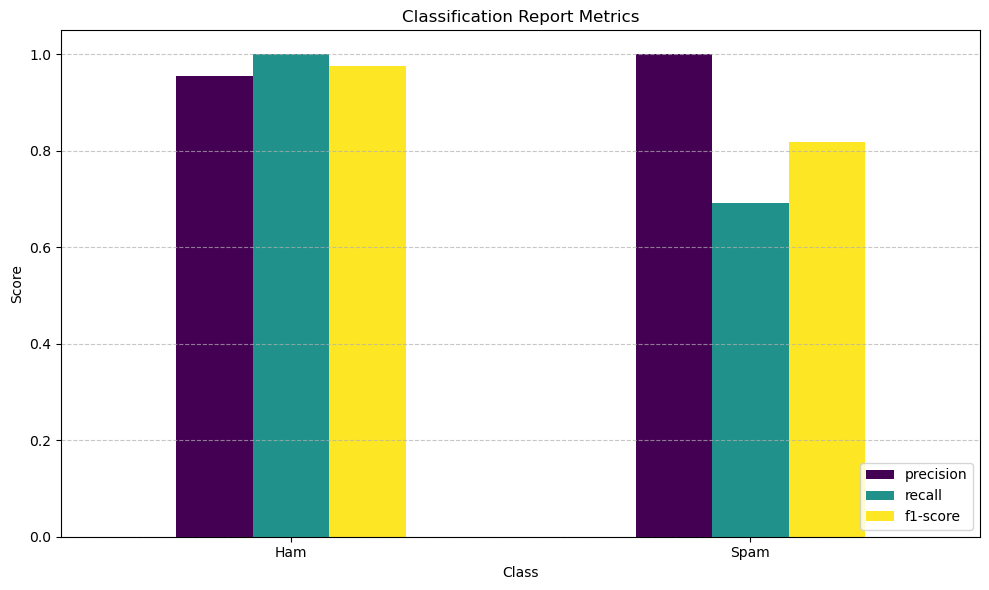

In [18]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Generate classification report
report = classification_report(y_test, X_test_prediction, target_names=['Ham', 'Spam'], output_dict=True)

# Convert report to DataFrame for easier plotting
df_report = pd.DataFrame(report).transpose()

# Drop 'accuracy' and 'macro avg' and 'weighted avg' rows for plotting class-specific metrics
df_report = df_report.drop(columns=['support'])
df_report = df_report.drop(index=['accuracy', 'macro avg', 'weighted avg'])

# Plotting the classification report
fig, ax = plt.subplots(figsize=(10, 6))
df_report[['precision', 'recall', 'f1-score']].plot(kind='bar', ax=ax, colormap='viridis')
plt.title('Classification Report Metrics')
plt.xlabel('Class')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Analyzing False Negatives to Improve Spam Recall

False negatives are messages that are actually spam but were incorrectly classified as 'ham'. Analyzing these messages can help us understand why the model failed to identify them as spam and potentially lead to improvements in our preprocessing or feature engineering steps.

In [19]:
# Get the indices of false negatives
# False negatives are where y_test is 1 (spam) and X_test_prediction is 0 (ham)
fn_indices = y_test[(y_test == 1) & (X_test_prediction == 0)].index

print(f"Number of False Negatives: {len(fn_indices)}")

# Retrieve the original messages corresponding to these false negatives
false_negative_messages = df.loc[fn_indices, ['Message', 'cleaned_message', 'Category']]

display(false_negative_messages)

Number of False Negatives: 46


,Message,cleaned_message,Category
3059,You are now unsubscribed all services. Get ton...,unsubscribed services get tons sexy babes hunk...,1
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling 3 weeks word back id like ...,1
1022,Guess what! Somebody you know secretly fancies...,guess somebody know secretly fancies wanna fin...,1
3750,Dear Voucher Holder 2 claim your 1st class air...,dear voucher holder 2 claim 1st class airport ...,1
856,Talk sexy!! Make new friends or fall in love i...,talk sexy make new friends fall love worlds di...,1
1793,WIN: We have a winner! Mr. T. Foley won an iPo...,win winner mr foley ipod exciting prizes soon ...,1
1663,Hi if ur lookin 4 saucy daytime fun wiv busty ...,hi ur lookin 4 saucy daytime fun wiv busty mar...,1
3981,ringtoneking 84484,ringtoneking 84484,1
4377,"If you don't, your prize will go to another cu...",dont prize go another customer tc wwwtcbiz 18 ...,1
3360,Sorry I missed your call let's talk when you h...,sorry missed call lets talk time im 07090201529,1


## Comparing with Random Forest Classifier

Let's train a Random Forest Classifier and compare its performance with the Logistic Regression model.

In [20]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42) # Using 100 estimators as a common starting point

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest Classifier model trained successfully!")

Random Forest Classifier model trained successfully!


### Random Forest Model Evaluation

Now, let's evaluate the Random Forest model's performance on the test data.

In [21]:
# Make predictions on the test data
X_test_prediction_rf = rf_model.predict(X_test)

# Evaluate the model accuracy on the test data
test_data_accuracy_rf = accuracy_score(y_test, X_test_prediction_rf)

print(f"Accuracy on Test data (Random Forest): {test_data_accuracy_rf:.4f}")

Accuracy on Test data (Random Forest): 0.9776


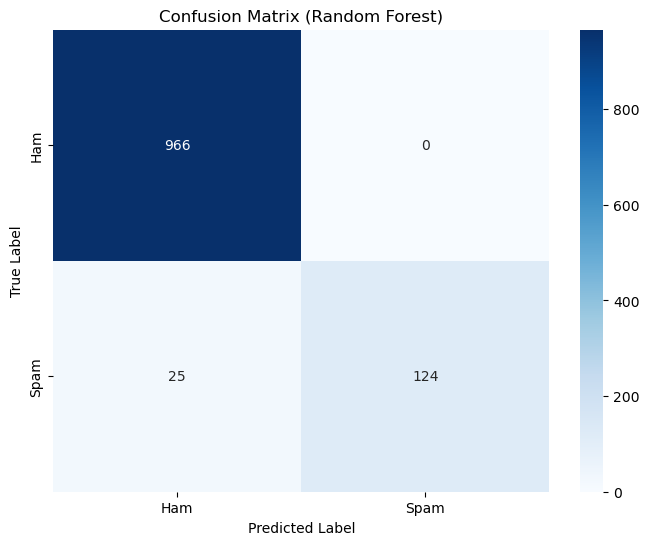

In [22]:
# Generate the confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, X_test_prediction_rf)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Random Forest)')
plt.show()

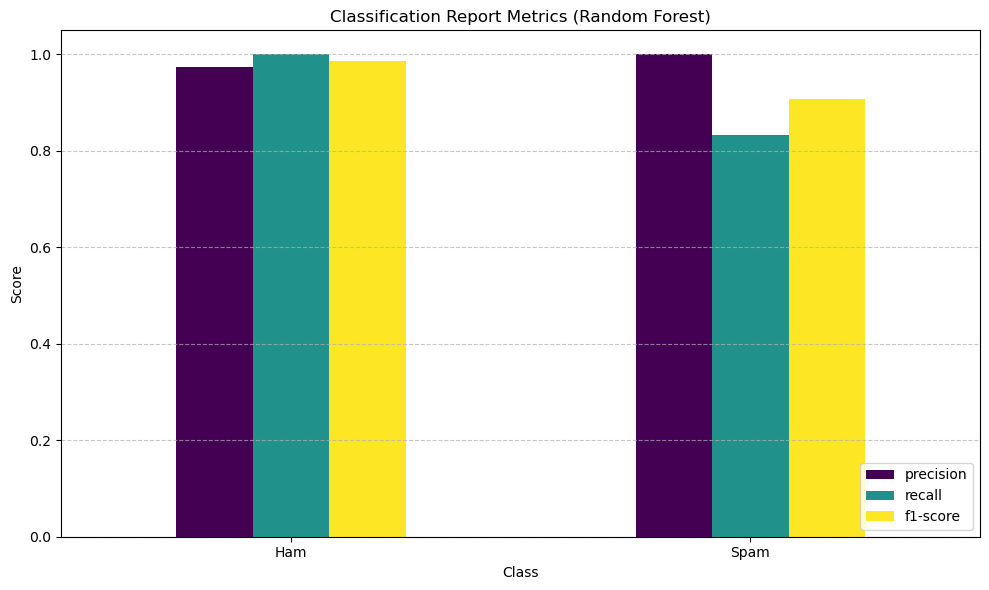

In [23]:
# Generate classification report for Random Forest
report_rf = classification_report(y_test, X_test_prediction_rf, target_names=['Ham', 'Spam'], output_dict=True)

# Convert report to DataFrame for easier plotting
df_report_rf = pd.DataFrame(report_rf).transpose()

# Drop 'accuracy' and 'macro avg' and 'weighted avg' rows for plotting class-specific metrics
df_report_rf = df_report_rf.drop(columns=['support'])
df_report_rf = df_report_rf.drop(index=['accuracy', 'macro avg', 'weighted avg'])

# Plotting the classification report
fig, ax = plt.subplots(figsize=(10, 6))
df_report_rf[['precision', 'recall', 'f1-score']].plot(kind='bar', ax=ax, colormap='viridis')
plt.title('Classification Report Metrics (Random Forest)')
plt.xlabel('Class')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Predictive System with Random Forest

Let's create a predictive function using the trained Random Forest model.

In [24]:
def predict_spam_rf(message):
    # Preprocess the message
    cleaned_message = message.lower()
    cleaned_message = remove_punctuation(cleaned_message)
    cleaned_message = remove_stopwords(cleaned_message)

    # Vectorize the cleaned message
    message_vector = tfidf_vectorizer.transform([cleaned_message])

    # Make prediction
    prediction = rf_model.predict(message_vector)

    # Return 'spam' or 'ham'
    if prediction[0] == 1:
        return 'spam'
    else:
        return 'ham'

print("Predictive function `predict_spam_rf` created.")

Predictive function `predict_spam_rf` created.


### Random Forest Demonstration

In [25]:
# Test with the same 'spam' message example
spam_message = "Congratulations! You've won a free iPhone. Click here to claim your prize: http://example.com/prize"
print(f"Message: '{spam_message}'\nRandom Forest Prediction: {predict_spam_rf(spam_message)}\n")

# Test with the same 'ham' message example
ham_message = "Hey, let's catch up tomorrow for coffee. Are you free in the afternoon?"
print(f"Message: '{ham_message}'\nRandom Forest Prediction: {predict_spam_rf(ham_message)}\n")

# Test with another 'spam' message (similar to one from the dataset)
spam_message_2 = "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18s"
print(f"Message: '{spam_message_2}'\nRandom Forest Prediction: {predict_spam_rf(spam_message_2)}\n")

Message: 'Congratulations! You've won a free iPhone. Click here to claim your prize: http://example.com/prize'
Random Forest Prediction: spam

Message: 'Hey, let's catch up tomorrow for coffee. Are you free in the afternoon?'
Random Forest Prediction: ham

Message: 'Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18s'
Random Forest Prediction: spam



## Hyperparameter Tuning for Random Forest

To potentially improve the Random Forest model further, we will perform hyperparameter tuning using `RandomizedSearchCV`. This method efficiently searches a defined parameter space to find the best combination of hyperparameters for our model.

In [30]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500], # Number of trees in the forest
    'max_features': ['sqrt', 'log2'], # Number of features to consider at every split
    'max_depth': [10, 20, 30, 40, 50, None], # Maximum number of levels in tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split a node
    'min_samples_leaf': [1, 2, 4], # Minimum number of samples required at each leaf node
    'bootstrap': [True, False] # Method for sampling data points (with or without replacement)
}

# Initialize RandomizedSearchCV
# n_iter: Number of parameter settings that are sampled. Trades off execution time with quality of solution.
# cv: Number of folds for cross-validation
rf_random = RandomizedSearchCV(estimator=rf_model, param_distributions=param_dist,
                               n_iter = 100, cv = 3, verbose=2, random_state=42, n_jobs = -1)

# Fit the random search model
rf_random.fit(X_train, y_train)

print("Randomized Search completed!")

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Randomized Search completed!


In [31]:
# Print the best parameters and best score found
print("Best parameters found:", rf_random.best_params_)
print("Best cross-validation score:", rf_random.best_score_)

# Get the best model from the search
best_rf_model = rf_random.best_estimator_

# Evaluate the best model on the test data
X_test_prediction_tuned = best_rf_model.predict(X_test)
test_data_accuracy_tuned = accuracy_score(y_test, X_test_prediction_tuned)

print(f"Accuracy on Test data (Tuned Random Forest): {test_data_accuracy_tuned:.4f}")

Best parameters found: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': False}
Best cross-validation score: 0.976216177023714
Accuracy on Test data (Tuned Random Forest): 0.9803


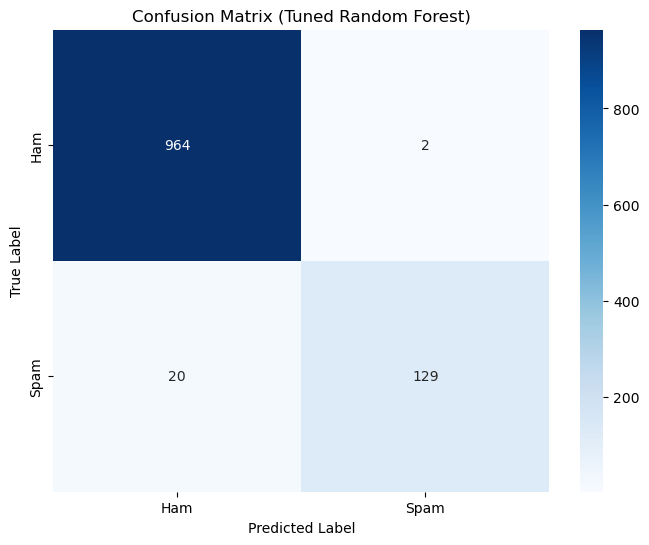

In [32]:
# Generate confusion matrix for the tuned Random Forest model
cm_tuned = confusion_matrix(y_test, X_test_prediction_tuned)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Tuned Random Forest)')
plt.show()

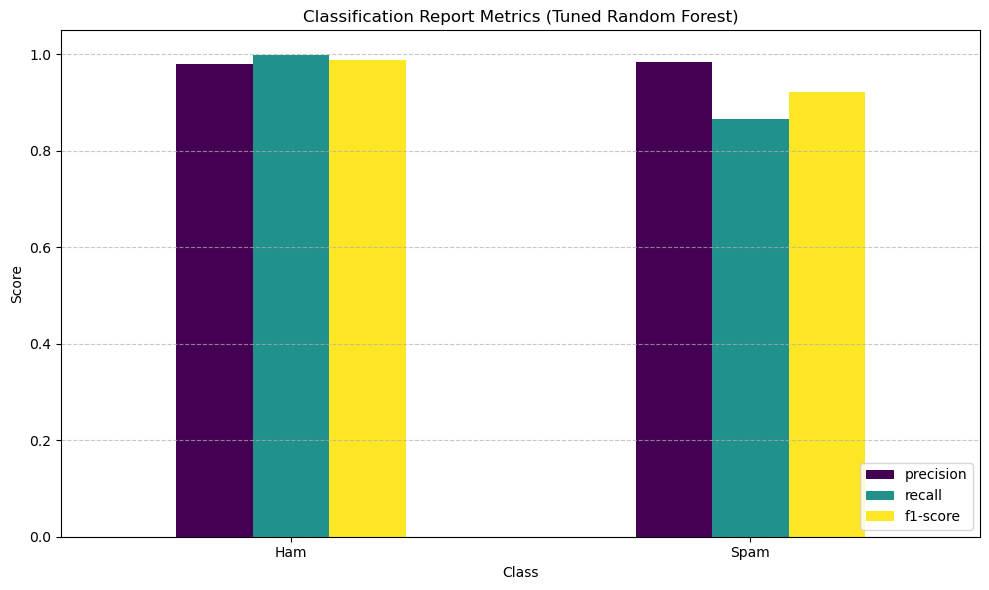

In [33]:
# Generate classification report for the tuned Random Forest
report_tuned = classification_report(y_test, X_test_prediction_tuned, target_names=['Ham', 'Spam'], output_dict=True)

# Convert report to DataFrame for easier plotting
df_report_tuned = pd.DataFrame(report_tuned).transpose()

# Drop 'accuracy' and 'macro avg' and 'weighted avg' rows for plotting class-specific metrics
df_report_tuned = df_report_tuned.drop(columns=['support'])
df_report_tuned = df_report_tuned.drop(index=['accuracy', 'macro avg', 'weighted avg'])

# Plotting the classification report
fig, ax = plt.subplots(figsize=(10, 6))
df_report_tuned[['precision', 'recall', 'f1-score']].plot(kind='bar', ax=ax, colormap='viridis')
plt.title('Classification Report Metrics (Tuned Random Forest)')
plt.xlabel('Class')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()